
# HITO 2 – Análisis de Datos y Formulación del Problema
## Proyecto VPER

Índice:

1) Introducción
2) Objetivo de la exploración inicial
3) Limpieza
4) Análisis de los datos
5) Agents


## 1. Introducción

Se analiza la estructura inicial del repositorio de datos utilizado en el proyecto Valorant Performance Evaluation Ranking (VPER), cuyo objetivo es desarrollar un sistema de inteligencia artificial capaz de evaluar el rendimiento individual de jugadores profesionales de Valorant.

Los datos no se encuentran consolidados en un único dataset listo para el análisis. En su lugar, el repositorio está organizado siguiendo una lógica similar a la de un data lake, donde la información se almacena de forma distribuida y segmentada por temporadas competitivas. Dentro de la carpeta principal /data existen distintas particiones anuales (vct_2021, vct_2022, ..., vct_2025) que contienen información específica de cada periodo, así como una carpeta global /all_ids que actúa como catálogo de identificadores del ecosistema competitivo.

Cada partición anual se divide a su vez en subcarpetas que representan diferentes tipos de información, como agents, ids, matches y player_stats, lo que permite separar las entidades principales del sistema competitivo. Esta organización facilita el almacenamiento histórico de los datos, aunque implica que el dataset final aún no está completamente consolidado y requiere procesos posteriores de integración y preparación antes de ser utilizado para modelado.

## 2. Objetivo

El objetivo de esta exploración inicial es comprender la organización del data lake y el papel de cada uno de sus componentes antes de realizar el análisis de datos. En particular, se busca identificar la estructura del repositorio, los diferentes tipos de archivos disponibles y cómo se relacionan entre sí las entidades principales del sistema competitivo, como jugadores, equipos, partidas y torneos.

Esta etapa es fundamental para establecer una base sólida para el análisis exploratorio de datos (EDA), ya que permitirá determinar qué fuentes contienen la información relevante para el proyecto, cómo deben integrarse los distintos conjuntos de datos y cuál será la unidad de análisis más adecuada para evaluar el rendimiento competitivo de los jugadores.

## 3. Limpieza

### 1) Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### 2) Definir las rutas del Data Lake

In [2]:
DATA_PATH = "data/vct_2025"

agents_path = os.path.join(DATA_PATH, "agents")
ids_path = os.path.join(DATA_PATH, "ids")
matches_path = os.path.join(DATA_PATH, "matches")
player_stats_path = os.path.join(DATA_PATH, "players_stats")

### 3) Cargar datasets principales

In [3]:
# Player stats (dataset principal)
player_stats = pd.read_csv(os.path.join(player_stats_path, "players_stats.csv"))

# IDs
players_ids = pd.read_csv(os.path.join(ids_path, "players_ids.csv"))
teams_ids = pd.read_csv(os.path.join(ids_path, "teams_ids.csv"))

# Matches
maps_scores = pd.read_csv(os.path.join(matches_path, "maps_scores.csv"))
overview = pd.read_csv(os.path.join(matches_path, "overview.csv"))

# Ver tamaño
print("player_stats:", player_stats.shape)
print("players_ids:", players_ids.shape)
print("teams_ids:", teams_ids.shape)
print("maps_scores:", maps_scores.shape)
print("overview:", overview.shape)

player_stats: (17996, 25)
players_ids: (349, 2)
teams_ids: (58, 2)
maps_scores: (1277, 16)
overview: (53226, 21)


### 4) Inspección inicial

* Información general

In [4]:
player_stats.head()

,Tournament,Stage,Match Type,Player,Teams,Agents,Rounds Played,Rating,Average Combat Score,Kills:Deaths,"Kill, Assist, Trade, Survive %",Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Headshot %,Clutch Success %,Clutches (won/played),Maximum Kills in a Single Map,Kills,Deaths,Assists,First Kills,First Deaths
0,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,astra,26,0.68,129.0,0.61,69%,89.0,0.42,0.15,0.12,0.12,44%,NaN,0/4,11,11,18,4,3,3
1,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,omen,19,0.46,98.0,0.40,42%,55.0,0.32,0.26,0.05,0.26,37%,33%,1/3,6,6,15,5,1,5
2,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,"astra, omen",45,0.59,114.0,0.52,58%,74.0,0.38,0.20,0.09,0.18,41%,14%,1/7,11,17,33,9,4,8
3,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,fade,26,1.21,219.0,1.13,81%,147.0,0.69,0.38,0.08,0.04,23%,33%,1/3,18,18,16,10,2,1
4,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,sova,19,1.02,220.0,0.75,58%,142.0,0.63,0.26,0.05,0.05,28%,NaN,0/4,12,12,16,5,1,1


* Información detallada

In [5]:

player_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Tournament                      17996 non-null  object 
 1   Stage                           17996 non-null  object 
 2   Match Type                      17996 non-null  object 
 3   Player                          17996 non-null  object 
 4   Teams                           17996 non-null  object 
 5   Agents                          17996 non-null  object 
 6   Rounds Played                   17996 non-null  int64  
 7   Rating                          16604 non-null  float64
 8   Average Combat Score            17986 non-null  float64
 9   Kills:Deaths                    17996 non-null  float64
 10  Kill, Assist, Trade, Survive %  16692 non-null  object 
 11  Average Damage Per Round        16626 non-null  float64
 12  Kills Per Round                 

* Estadísctica descriptiva

In [6]:
player_stats.describe()

,Rounds Played,Rating,Average Combat Score,Kills:Deaths,Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Maximum Kills in a Single Map,Kills,Deaths,Assists,First Kills,First Deaths
count,17996.000000,16604.000000,17986.000000,17996.000000,16626.000000,17996.000000,17996.000000,16645.000000,16646.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000
mean,56.905979,0.988747,195.649283,1.036644,128.316312,0.688337,0.279657,0.099878,0.101812,16.917648,39.377195,39.402367,16.060736,5.273727,5.281118
std,73.473854,0.275065,49.065678,0.451347,30.629254,0.192783,0.147140,0.071383,0.068724,5.739903,52.716300,50.380248,23.288620,8.685712,8.120614
min,13.000000,0.030000,22.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,0.820000,163.000000,0.770000,108.000000,0.560000,0.170000,0.050000,0.050000,13.000000,15.000000,15.000000,5.000000,1.000000,1.000000
50%,37.000000,0.980000,193.000000,0.980000,127.000000,0.680000,0.260000,0.090000,0.090000,17.000000,24.000000,24.000000,9.000000,3.000000,3.000000
75%,61.000000,1.150000,225.000000,1.210000,146.000000,0.800000,0.360000,0.140000,0.140000,21.000000,41.000000,41.000000,17.000000,6.000000,6.000000
max,696.000000,2.660000,509.000000,18.000000,307.000000,1.950000,1.570000,0.500000,0.530000,42.000000,579.000000,485.000000,345.000000,137.000000,111.000000


### 5) Verificar valores nulos

In [7]:
player_stats.isnull().sum().sort_values(ascending=False)

Clutch Success %                  11337
Clutches (won/played)              4733
Rating                             1392
Average Damage Per Round           1370
First Kills Per Round              1351
First Deaths Per Round             1350
Headshot %                         1308
Kill, Assist, Trade, Survive %     1304
Average Combat Score                 10
Agents                                0
Rounds Played                         0
Player                                0
Teams                                 0
Match Type                            0
Stage                                 0
Tournament                            0
Kills:Deaths                          0
Assists Per Round                     0
Kills Per Round                       0
Maximum Kills in a Single Map         0
Kills                                 0
Deaths                                0
Assists                               0
First Kills                           0
First Deaths                          0


### 6) Identificar columnas a trabajar

In [9]:
player_stats.columns

Index(['Tournament', 'Stage', 'Match Type', 'Player', 'Teams', 'Agents',
       'Rounds Played', 'Rating', 'Average Combat Score', 'Kills:Deaths',
       'Kill, Assist, Trade, Survive %', 'Average Damage Per Round',
       'Kills Per Round', 'Assists Per Round', 'First Kills Per Round',
       'First Deaths Per Round', 'Headshot %', 'Clutch Success %',
       'Clutches (won/played)', 'Maximum Kills in a Single Map', 'Kills',
       'Deaths', 'Assists', 'First Kills', 'First Deaths'],
      dtype='object')

### 7) Limpieza de columnas innecesarias

In [10]:
columns_to_keep = [
    "Player",
    "Agents",
    "Kills",
    "Deaths",
    "Assists",
    "Average Damage Per Round",
    "Assists Per Round",
    "Kills Per Round",
    "First Kills",
    "First Deaths"
]

player_stats_clean = player_stats[columns_to_keep].copy()
player_stats_clean.head()

,Player,Agents,Kills,Deaths,Assists,Average Damage Per Round,Assists Per Round,Kills Per Round,First Kills,First Deaths
0,Boo,astra,11,18,4,89.0,0.15,0.42,3,3
1,Boo,omen,6,15,5,55.0,0.26,0.32,1,5
2,Boo,"astra, omen",17,33,9,74.0,0.20,0.38,4,8
3,RieNs,fade,18,16,10,147.0,0.38,0.69,2,1
4,RieNs,sova,12,16,5,142.0,0.26,0.63,1,1


### 8) Verificar Dataset

In [11]:
player_stats_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Player                    17996 non-null  object 
 1   Agents                    17996 non-null  object 
 2   Kills                     17996 non-null  int64  
 3   Deaths                    17996 non-null  int64  
 4   Assists                   17996 non-null  int64  
 5   Average Damage Per Round  16626 non-null  float64
 6   Assists Per Round         17996 non-null  float64
 7   Kills Per Round           17996 non-null  float64
 8   First Kills               17996 non-null  int64  
 9   First Deaths              17996 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 1.4+ MB


In [12]:
print("Dimensiones:", player_stats_clean.shape)
print("\nValores nulos por columna:")
print(player_stats_clean.isnull().sum())

print("\nDuplicados:")
print(player_stats_clean.duplicated().sum())

player_stats_clean.info()

Dimensiones: (17996, 10)

Valores nulos por columna:
Player                         0
Agents                         0
Kills                          0
Deaths                         0
Assists                        0
Average Damage Per Round    1370
Assists Per Round              0
Kills Per Round                0
First Kills                    0
First Deaths                   0
dtype: int64

Duplicados:
993
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Player                    17996 non-null  object 
 1   Agents                    17996 non-null  object 
 2   Kills                     17996 non-null  int64  
 3   Deaths                    17996 non-null  int64  
 4   Assists                   17996 non-null  int64  
 5   Average Damage Per Round  16626 non-null  float64
 6   Assists Per Round         17996 n

In [13]:
player_stats_clean = player_stats_clean.drop_duplicates()
player_stats_clean.head()

,Player,Agents,Kills,Deaths,Assists,Average Damage Per Round,Assists Per Round,Kills Per Round,First Kills,First Deaths
0,Boo,astra,11,18,4,89.0,0.15,0.42,3,3
1,Boo,omen,6,15,5,55.0,0.26,0.32,1,5
2,Boo,"astra, omen",17,33,9,74.0,0.20,0.38,4,8
3,RieNs,fade,18,16,10,147.0,0.38,0.69,2,1
4,RieNs,sova,12,16,5,142.0,0.26,0.63,1,1


## 4. Analisis de los datos

### 1) Visualizar cuantos jugadores hay

In [ ]:
print("Número de jugadores únicos:", player_stats_clean["Player"].nunique())

Número de jugadores únicos: 313
Número de combinaciones de agentes: 1001


In [18]:
player_stats_clean["Player"].value_counts().head(10)

Player
Alfajer    144
paTiTek    138
keiko      131
kamo       129
kaajak     128
JonahP     125
iZu        124
Meteor     123
N4RRATE    122
Zellsis    122
Name: count, dtype: int64

### 2) Distribución de métricas principales

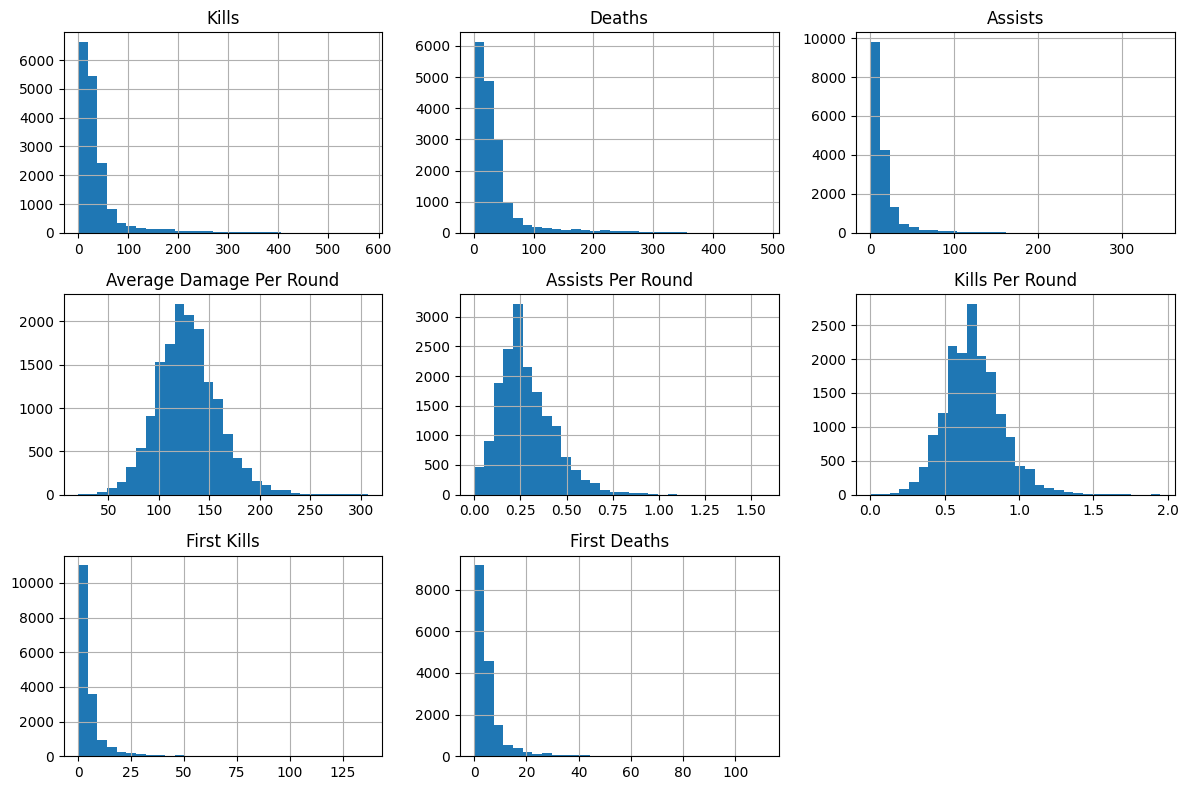

In [20]:
player_stats_clean.hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

### 3) Detectar outliers

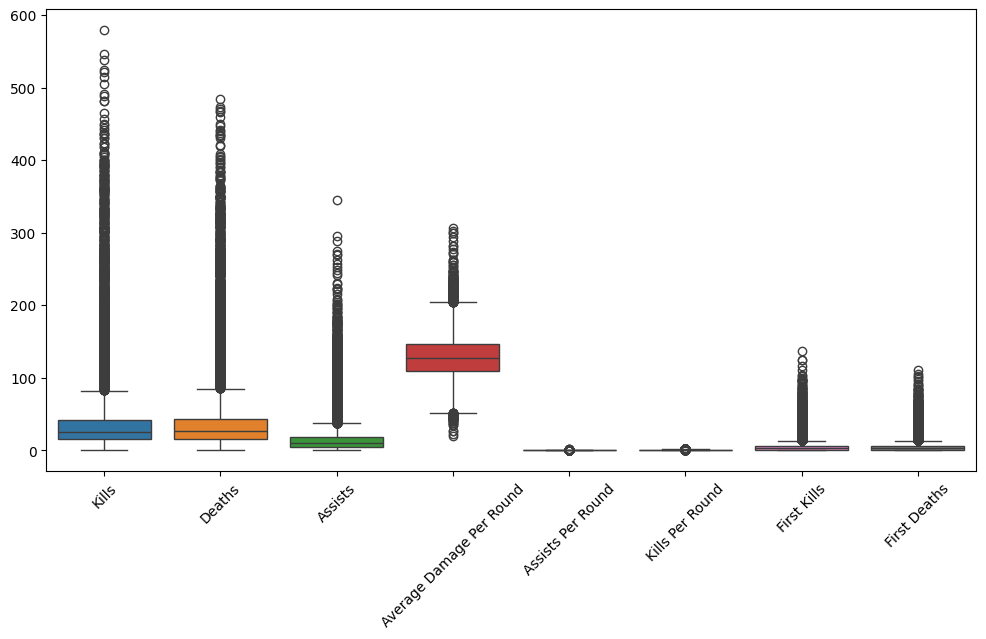

In [21]:
plt.figure(figsize=(12,6))

sns.boxplot(data=player_stats_clean)

plt.xticks(rotation=45)
plt.show()

### 4) Matriz de correlación

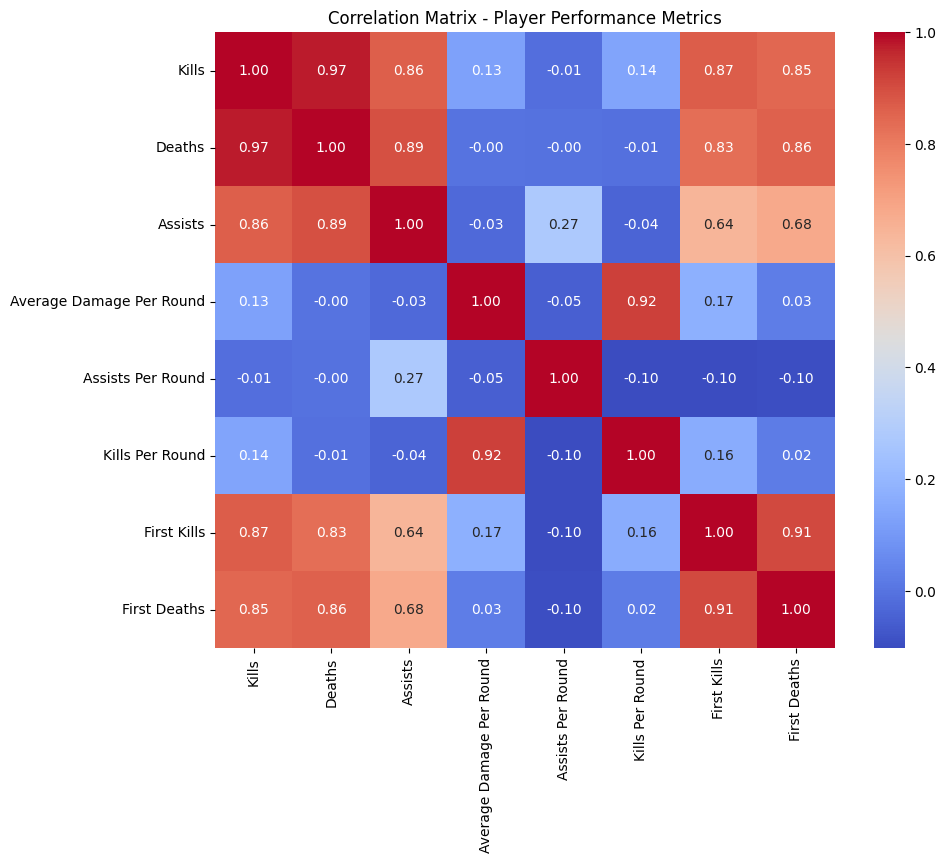

In [23]:
corr_matrix = player_stats_clean.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - Player Performance Metrics")
plt.show()

### 5) Relación entre daño y kills

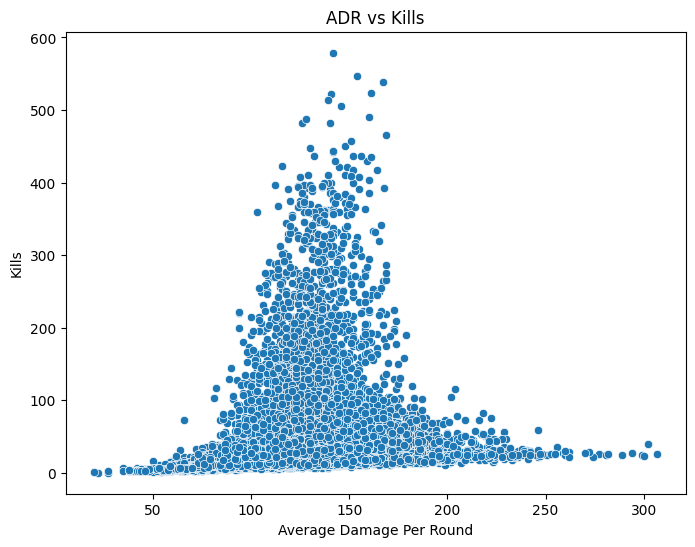

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Average Damage Per Round",
    y="Kills",
    data=player_stats_clean
)

plt.title("ADR vs Kills")
plt.show()

### 6) Rendimiento promedio por jugador

In [25]:
player_performance = (
    player_stats_clean
    .groupby("Player")
    .mean(numeric_only=True)
    .sort_values("Kills Per Round", ascending=False)
)

player_performance.head(10)

,Kills,Deaths,Assists,Average Damage Per Round,Assists Per Round,Kills Per Round,First Kills,First Deaths
Player,,,,,,,,
Sato,52.290323,43.612903,9.806452,163.000000,0.168065,0.898710,10.677419,10.677419
OXY,49.935484,44.725806,10.290323,158.322581,0.175484,0.888710,11.435484,10.290323
ZmjjKK,51.278261,45.017391,12.573913,153.481928,0.215478,0.877304,8.356522,8.504348
slowly,43.846154,33.846154,14.557692,158.410256,0.282308,0.866538,5.500000,4.423077
whzy,57.968085,49.329787,13.723404,158.297297,0.205638,0.865000,10.010638,8.457447
Cryocells,45.161765,35.632353,11.794118,153.632353,0.219118,0.861618,6.941176,4.955882
aspas,54.863636,40.443182,8.784091,153.988636,0.145114,0.860455,12.068182,7.409091
Meiy,41.629630,35.777778,7.759259,149.981481,0.154074,0.855926,7.000000,5.500000
stew,46.326923,38.750000,10.153846,153.882353,0.184615,0.852885,7.230769,5.769231


### 7) Ranking preliminar simple

In [26]:
player_stats_clean["simple_score"] = (
    player_stats_clean["Kills Per Round"]
    + player_stats_clean["Assists Per Round"]
    + player_stats_clean["Average Damage Per Round"] / 100
    - player_stats_clean["First Deaths"] * 0.1
)

player_stats_clean.sort_values("simple_score", ascending=False).head(10)

,Player,Agents,Kills,Deaths,Assists,Average Damage Per Round,Assists Per Round,Kills Per Round,First Kills,First Deaths,simple_score
13116,jawgemo,yoru,27,7,5,294.0,0.36,1.93,2,1,5.13
14122,nAts,viper,25,8,5,289.0,0.36,1.79,3,0,5.04
10207,sociablEE,sova,26,4,7,282.0,0.47,1.73,2,0,5.02
11115,f0rsakeN,neon,26,5,3,307.0,0.20,1.73,3,0,5.00
5715,Rarga,sage,23,4,12,247.0,0.86,1.64,2,0,4.97
5974,stew,raze,25,6,8,299.0,0.47,1.47,2,0,4.93
4674,Meiy,jett,39,11,1,302.0,0.05,1.95,3,1,4.92
9987,kamo,waylay,23,7,5,300.0,0.36,1.64,7,1,4.90
3222,keznit,yoru,22,6,8,274.0,0.57,1.57,4,0,4.88
9967,hiro,vyse,22,2,7,262.0,0.54,1.69,1,0,4.85


### 8) Guardar el dataset

In [28]:
player_stats_clean.to_csv("dataset_players_stats.csv", index=False)

## 5. Agents

### 1) Visualizar su distribución

In [31]:
print("Número de combinaciones de agentes:", player_stats_clean["Agents"].nunique())
player_stats_clean["Agents"].value_counts().head(20)

Número de combinaciones de agentes: 1001


Agents
omen           1268
viper          1032
sova            897
fade            766
cypher          759
yoru            743
raze            663
vyse            649
breach          616
tejo            595
jett            570
neon            569
killjoy         527
astra           468
kayo            420
brimstone       404
deadlock        246
fade, sova      243
gekko           187
astra, omen     165
Name: count, dtype: int64

In [32]:
multi_agents = player_stats_clean["Agents"].str.contains(",")

print("Filas con múltiples agentes:", multi_agents.sum())
print("Porcentaje:", multi_agents.mean()*100)

Filas con múltiples agentes: 4799
Porcentaje: 28.224430982767746


### 2) Visualizr agentes individuales

In [33]:
all_agents = (
    player_stats_clean["Agents"]
    .str.split(",")
    .explode()
    .str.strip()
)

all_agents.value_counts()

Agents
omen         2351
viper        2056
sova         1746
fade         1542
cypher       1505
yoru         1408
raze         1338
vyse         1322
breach       1224
jett         1145
neon         1142
tejo         1123
killjoy      1094
astra         975
kayo          875
brimstone     861
deadlock      517
gekko         398
chamber       308
waylay        302
iso           268
skye          266
sage          238
harbor        173
clove          96
phoenix        70
reyna          38
Name: count, dtype: int64

### 3) Visualizar agentes mas utilizados

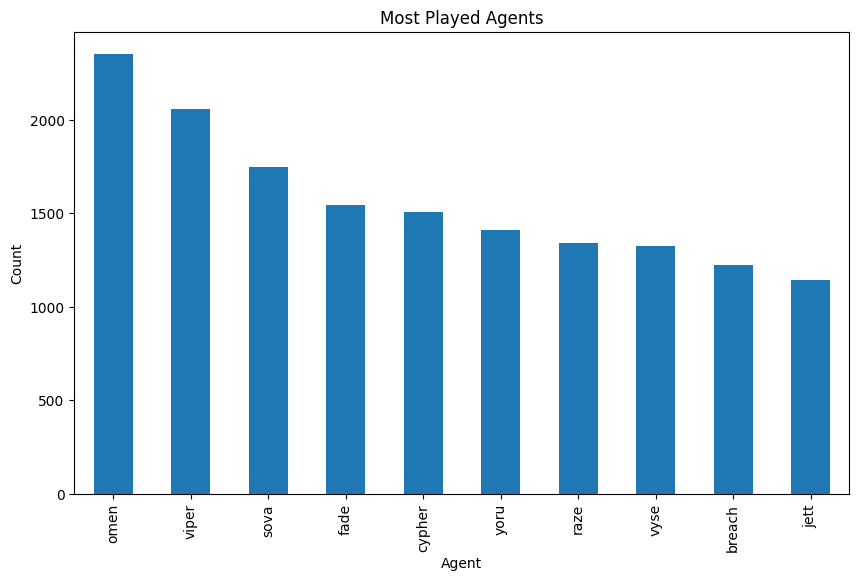

In [34]:
plt.figure(figsize=(10,6))

all_agents.value_counts().head(10).plot(
    kind="bar"
)

plt.title("Most Played Agents")
plt.ylabel("Count")
plt.xlabel("Agent")
plt.show()

### 4) Tratamiento de duplicados

In [35]:
player_agents_expanded = player_stats_clean.copy()

player_agents_expanded["Agents"] = (
    player_agents_expanded["Agents"]
    .str.split(",")
)

player_agents_expanded = player_agents_expanded.explode("Agents")

player_agents_expanded["Agents"] = player_agents_expanded["Agents"].str.strip()

player_agents_expanded.head()

,Player,Agents,Kills,Deaths,Assists,Average Damage Per Round,Assists Per Round,Kills Per Round,First Kills,First Deaths,simple_score
0,Boo,astra,11,18,4,89.0,0.15,0.42,3,3,1.16
1,Boo,omen,6,15,5,55.0,0.26,0.32,1,5,0.63
2,Boo,astra,17,33,9,74.0,0.20,0.38,4,8,0.52
2,Boo,omen,17,33,9,74.0,0.20,0.38,4,8,0.52
3,RieNs,fade,18,16,10,147.0,0.38,0.69,2,1,2.44


### 5) Rendimiento promedio por agente

In [36]:
agent_performance = (
    player_agents_expanded
    .groupby("Agents")
    .mean(numeric_only=True)
    .sort_values("Kills Per Round", ascending=False)
)

agent_performance

,Kills,Deaths,Assists,Average Damage Per Round,Assists Per Round,Kills Per Round,First Kills,First Deaths,simple_score
Agents,,,,,,,,,
jett,64.236681,58.204367,13.689956,145.240076,0.154742,0.803467,13.305677,11.822707,1.129688
phoenix,70.714286,64.500000,24.171429,144.828125,0.289714,0.783000,10.428571,10.671429,1.337031
reyna,100.315789,94.236842,27.947368,147.657895,0.210263,0.779737,20.605263,18.947368,0.571842
raze,64.814649,60.796712,16.455157,146.162141,0.187377,0.779200,12.656203,11.955904,1.151917
waylay,76.751656,71.172185,19.453642,139.091549,0.178344,0.777020,15.086093,14.129139,0.846972
chamber,65.386364,60.340909,15.941558,139.385382,0.163669,0.774416,11.301948,9.720779,1.333787
yoru,67.034801,62.900568,18.291903,140.192708,0.208395,0.773416,13.421165,12.544034,1.069360
neon,65.345009,62.035902,17.485989,140.735209,0.203984,0.771690,12.734676,12.542032,0.993928
iso,72.000000,67.078358,21.197761,144.060150,0.218955,0.770522,11.626866,10.701493,1.353534


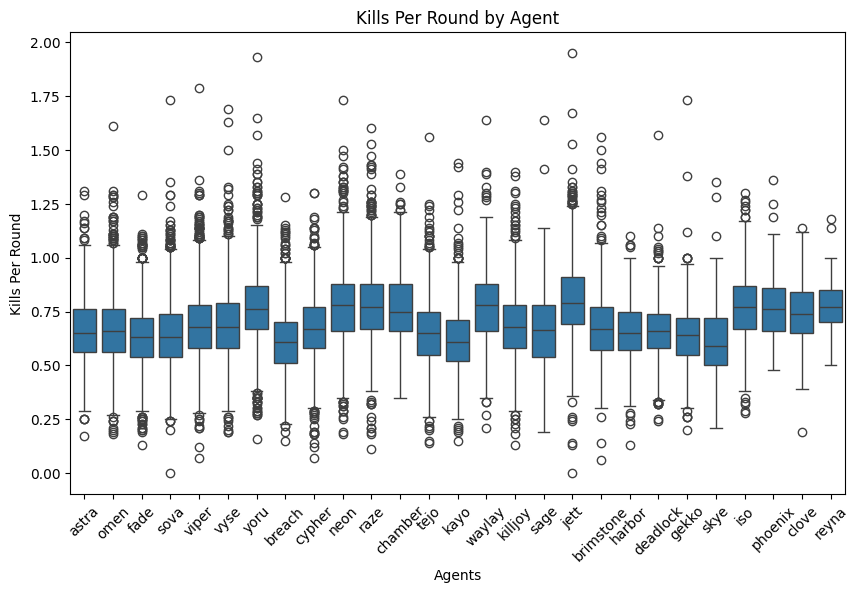

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Agents",
    y="Kills Per Round",
    data=player_agents_expanded
)

plt.xticks(rotation=45)
plt.title("Kills Per Round by Agent")
plt.show()